In [4]:
from pathlib import Path
import json
import pandas as pd

In [26]:
# Change this to the folder that contains all participant folders
ROOT_DIR = Path("/Users/joanna.luberadzka/Projects/2026/chataid-web-test-analysis/data")

# JSON filenames inside each participant folder.
# Set both to the same file if one file contains both types of data.
# Switch either to a newer/alternative file to compare results.
CLARIFICATION_JSON = "experiment_data_plus_analysis.json"  # source for clarification_requests_*
SCORES_JSON        = "experiment_data_ICS_by_joa.json"  # source for experiment_userinput_scores

In [27]:
def _load_json(participant_dir, filename):
    path = participant_dir / filename
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

rows = []
SKIP = {"experiment_Joanna_1779782845088"}

for participant_dir in ROOT_DIR.iterdir():
    if participant_dir.name in SKIP or not participant_dir.is_dir():
        continue

    clarif_data = _load_json(participant_dir, CLARIFICATION_JSON)
    scores_data = _load_json(participant_dir, SCORES_JSON)

    if clarif_data is None and scores_data is None:
        print(f"Skipping {participant_dir.name}: neither JSON found")
        continue
    elif clarif_data is None:
        print(f"Warning {participant_dir.name}: {CLARIFICATION_JSON} not found, clarification columns will be empty")
    elif scores_data is None:
        print(f"Warning {participant_dir.name}: {SCORES_JSON} not found, score columns will be empty")

    base_source = clarif_data or scores_data
    participant_info = base_source.get("participant", {})
    metadata = base_source.get("metadata", {})

    base_row = {
        "participant_folder": participant_dir.name,
        "exportId": base_source.get("exportId"),
        "alias": participant_info.get("alias"),
        "age": participant_info.get("age"),
        "gender": participant_info.get("gender"),
        "isNativeSpeaker": participant_info.get("isNativeSpeaker"),
        "hearingStatus": participant_info.get("hearingStatus"),
        "isListeningExpert": participant_info.get("isListeningExpert"),
        "usingHeadphones": participant_info.get("usingHeadphones"),
        "appVersion": metadata.get("appVersion"),
        "timestamp": metadata.get("timestamp"),
    }

    # Information collection scores (from SCORES_JSON)
    if scores_data is not None:
        exp_userinput_answers   = scores_data.get("experiment_userinput", {})
        exp_userinput_scores    = scores_data.get("analysis", {}).get("experiment_userinput_scores", {})
        train_userinput_answers = scores_data.get("training_userinput", {})
        train_userinput_scores  = scores_data.get("analysis", {}).get("training_userinput_scores", {})
    else:
        exp_userinput_answers = exp_userinput_scores = {}
        train_userinput_answers = train_userinput_scores = {}

    # Clarification requests (from CLARIFICATION_JSON)
    if clarif_data is not None:
        exp_repetition_requests   = clarif_data.get("analysis", {}).get("clarification_requests_experiment", {})
        exp_repetition_examples   = clarif_data.get("analysis", {}).get("clarification_examples_experiment", {})
        train_repetition_requests = clarif_data.get("analysis", {}).get("clarification_requests_training", {})
        train_repetition_examples = clarif_data.get("analysis", {}).get("clarification_examples_training", {})
    else:
        exp_repetition_requests = exp_repetition_examples = {}
        train_repetition_requests = train_repetition_examples = {}

    row = {
        **base_row,
        **{f"train_ans_{k}": v   for k, v in train_userinput_answers.items()},
        **{f"train_score_{k}": v for k, v in train_userinput_scores.items()},
        **{f"exp_ans_{k}": v     for k, v in exp_userinput_answers.items()},
        **{f"exp_score_{k}": v   for k, v in exp_userinput_scores.items()},
        "exp_repetition_requests":    exp_repetition_requests,
        "exp_repetition_examples":    exp_repetition_examples,
        "train_repetition_requests":  train_repetition_requests,
        "train_repetition_examples":  train_repetition_examples,
    }
    rows.append(row)

df = pd.DataFrame(rows)

train_score_cols = [c for c in df.columns if c.startswith("train_score_")]
exp_score_cols   = [c for c in df.columns if c.startswith("exp_score_")]
df["train_pct_correct"] = df[train_score_cols].sum(axis=1) / len(train_score_cols) * 100
df["exp_pct_correct"]   = df[exp_score_cols].sum(axis=1)   / len(exp_score_cols)   * 100

N_TRAIN_ITEMS = 4
N_EXP_ITEMS   = 10
df["train_repetition_requests_per_item"] = df["train_repetition_requests"] / N_TRAIN_ITEMS
df["exp_repetition_requests_per_item"]   = df["exp_repetition_requests"]   / N_EXP_ITEMS

def extract_snr(app_version):
    if app_version is None:
        return None
    if "SNR=-5" in app_version:
        return -5
    elif "SNR=5" in app_version:
        return 5
    return None

df["SNR_condition"] = df["appVersion"].apply(extract_snr)

In [28]:
df.head(10)

,participant_folder,exportId,alias,age,gender,isNativeSpeaker,hearingStatus,isListeningExpert,usingHeadphones,appVersion,...,exp_score_Cafe closing time,exp_repetition_requests,exp_repetition_examples,train_repetition_requests,train_repetition_examples,train_pct_correct,exp_pct_correct,train_repetition_requests_per_item,exp_repetition_requests_per_item,SNR_condition
0,experiment_White_Thunder_1779965899475,White_Thunder_1779965899475,White_Thunder,24,Male,no,Normal hearing,no,yes,App version: V0.1.4(ZIP+FIREBASE checkpoint) S...,...,0.0,2,"[Can you repeat what the milk options are?, Ye...",0,[],100.00,65.0,0.00,0.2,-5
1,experiment_PeterParker_1779964909506,PeterParker_1779964909506,PeterParker,31,Male,no,Normal hearing,no,yes,App version: V0.1.4(ZIP+FIREBASE checkpoint) S...,...,1.0,13,"[Sorry, I didn't get that., Could you please r...",3,"[Sorry, can you repeat that?, Just to make sur...",100.00,100.0,0.75,1.3,-5
2,experiment_enric2_1779783743900,enric2_1779783743900,enric2,34,Male,no,Normal hearing,yes,yes,App version: V0.1.4(ZIP+FIREBASE checkpoint) S...,...,1.0,0,[],0,[],100.00,100.0,0.00,0.0,5
3,experiment_Gerard_1780157613344,Gerard_1780157613344,Gerard,35,Male,no,Normal hearing,no,yes,App version: V0.1.4(ZIP+FIREBASE checkpoint) S...,...,1.0,5,"[Which milk did you first mention?, Can you re...",2,"[What was the last museum you mentioned?, Yeah...",100.00,100.0,0.50,0.5,-5
4,experiment_Albert Barreiro_1779785968775,Albert Barreiro_1779785968775,Albert Barreiro,27,Male,no,Normal hearing,no,yes,App version: V0.1.4(ZIP+FIREBASE checkpoint) S...,...,1.0,8,"[Can you repeat it, please?, Uh, repeat the la...",5,"[Wait, can you repeat the sea water temperatur...",100.00,95.0,1.25,0.8,5
5,experiment_Pol_1779812000287,Pol_1779812000287,Pol,22,Male,no,Normal hearing,no,yes,App version: V0.1.4(ZIP+FIREBASE checkpoint) S...,...,1.0,1,[what was the the artist's name? Barcelona what?],1,"[sorry, which was the last museum you told me?]",100.00,100.0,0.25,0.1,5
6,experiment_Álvaro Díaz_1779976543878,Álvaro Díaz_1779976543878,Álvaro Díaz,23,Male,no,Normal hearing,no,yes,App version: V0.1.4(ZIP+FIREBASE checkpoint) S...,...,1.0,10,"[Hi, can you repeat, please?, Can you repeat t...",1,[what did you say for the first one? Which is ...,93.75,62.5,0.25,1.0,-5
7,experiment_Riri_1779974812966,Riri_1779974812966,Riri,29,Female,no,Normal hearing,no,yes,App version: V0.1.4(ZIP+FIREBASE checkpoint) S...,...,1.0,11,"[Eh, sorry. Can you repeat?, Eh, can you repea...",1,[Can you please repeat the list of museums tha...,100.00,97.5,0.25,1.1,-5
8,experiment_Oriol Marín_1780299590092,Oriol Marín_1780299590092,Oriol Marín,25,Male,no,Normal hearing,no,yes,App version: V0.1.4(ZIP+FIREBASE checkpoint) S...,...,1.0,19,"[Could you repeat that?, Yeah, I would like to...",1,"[Could you repeat that, please?]",100.00,87.5,0.25,1.9,-5
9,experiment_Julien_1779802077179,Julien_1779802077179,Julien,43,Male,no,Normal hearing,yes,yes,App version: V0.1.4(ZIP+FIREBASE checkpoint) S...,...,1.0,1,[Yes. And what's the artist's name?],0,[],100.00,92.5,0.00,0.1,5


In [29]:
df.columns


Index(['participant_folder', 'exportId', 'alias', 'age', 'gender',
       'isNativeSpeaker', 'hearingStatus', 'isListeningExpert',
       'usingHeadphones', 'appVersion', 'timestamp',
       'train_ans_Price of a single metro ticket',
       'train_ans_Current sea water temperature',
       'train_ans_Which museums have free admission today',
       'train_ans_Tourist office closing time',
       'train_score_Price of a single metro ticket',
       'train_score_Current sea water temperature',
       'train_score_Which museums have free admission today',
       'train_score_Tourist office closing time',
       'exp_ans_Price of a coffee with milk', 'exp_ans_Milk options available',
       'exp_ans_Is vegan milk more expensive?',
       'exp_ans_What is the cafe's specialty cake?',
       'exp_ans_Wi-Fi network name', 'exp_ans_Wi-Fi password',
       'exp_ans_Maximum table usage duration', 'exp_ans_Evening event',
       'exp_ans_Artist's name', 'exp_ans_Cafe closing time',
       'exp_s

In [30]:
# save to CSV
df.to_csv("all_objective_data.csv", index=False)


/var/folders/hz/fwwq053j7w579c9rw1shw5243xvlkw/T/ipykernel_50368/3571040358.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x="condition", y="pct_correct", order=order,


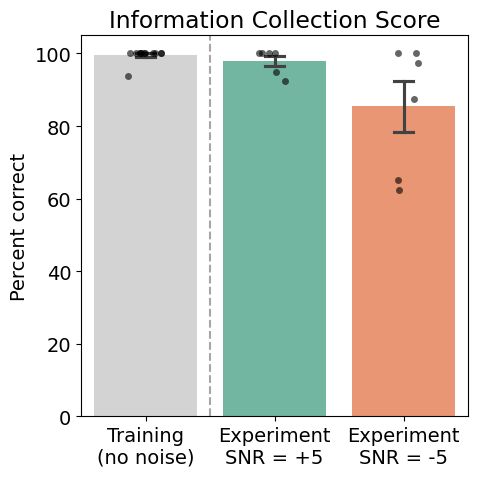

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Set the font size for better readability
plt.rcParams.update({'font.size': 14})

plot_data = pd.concat([
    pd.DataFrame({
        "condition": "Training\n(no noise)",
        "pct_correct": df["train_pct_correct"],
    }),
    pd.DataFrame({
        "condition": "Experiment\nSNR = +5",
        "pct_correct": df.loc[df["SNR_condition"] == 5, "exp_pct_correct"],
    }),
    pd.DataFrame({
        "condition": "Experiment\nSNR = -5",
        "pct_correct": df.loc[df["SNR_condition"] == -5, "exp_pct_correct"],
    }),
], ignore_index=True)

order = ["Training\n(no noise)", "Experiment\nSNR = +5", "Experiment\nSNR = -5"]

fig, ax = plt.subplots(figsize=(5, 5))
sns.barplot(data=plot_data, x="condition", y="pct_correct", order=order,
            palette=["lightgray", "#66c2a5", "#fc8d62"],
            errorbar="se", capsize=0.15, ax=ax)
sns.stripplot(data=plot_data, x="condition", y="pct_correct", order=order,
              color="black", alpha=0.6, jitter=0.15, ax=ax)
ax.axvline(x=0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_ylabel("Percent correct")
ax.set_xlabel("")
ax.set_ylim(0, 105)
ax.set_title("Information Collection Score")
plt.tight_layout()
plt.show()

/var/folders/hz/fwwq053j7w579c9rw1shw5243xvlkw/T/ipykernel_50368/2853462417.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x="condition", y="clarifications", order=order,


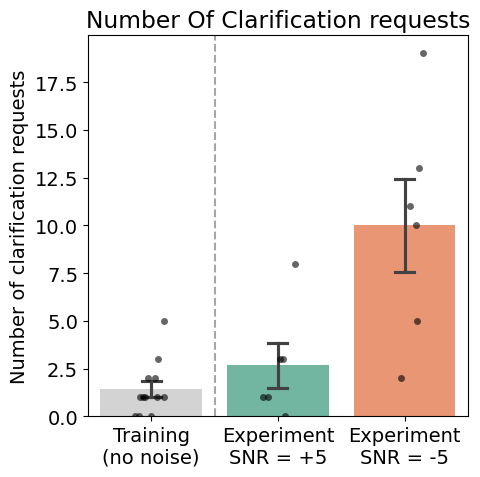

In [25]:
plot_data = pd.concat([
    pd.DataFrame({
        "condition": "Training\n(no noise)",
        "clarifications": df["train_repetition_requests"],
    }),
    pd.DataFrame({
        "condition": "Experiment\nSNR = +5",
        "clarifications": df.loc[df["SNR_condition"] == 5, "exp_repetition_requests"],
    }),
    pd.DataFrame({
        "condition": "Experiment\nSNR = -5",
        "clarifications": df.loc[df["SNR_condition"] == -5, "exp_repetition_requests"],
    }),
], ignore_index=True)

order = ["Training\n(no noise)", "Experiment\nSNR = +5", "Experiment\nSNR = -5"]

fig, ax = plt.subplots(figsize=(5, 5))
sns.barplot(data=plot_data, x="condition", y="clarifications", order=order,
            palette=["lightgray", "#66c2a5", "#fc8d62"],
            errorbar="se", capsize=0.15, ax=ax)
sns.stripplot(data=plot_data, x="condition", y="clarifications", order=order,
              color="black", alpha=0.6, jitter=0.15, ax=ax)
ax.axvline(x=0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)
ax.set_ylabel("Number of clarification requests")
ax.set_xlabel("")
ax.set_title("Number Of Clarification requests")
plt.tight_layout()
plt.show()